In [1]:
%load_ext autoreload
%autoreload 2

import torch
from torch import nn
from torch.utils.data import random_split, DataLoader, Subset
from torchvision import datasets
from torchvision.transforms import ToTensor

import os
import pandas as pd
from torch.utils.data import Dataset
# import sklearn
from sklearn.model_selection import train_test_split
from torchvision.transforms import ToTensor, Lambda
import matplotlib.colors as mcolors

from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
import sys
sys.path.insert(0, '../')
from utils import *
import matplotlib.pyplot as plt
import wandb
import datetime

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sn
import numpy as np
import matplotlib.colors as mcolors
from matplotlib import rc
plt.rc("text", usetex=True)  # Enable LaTeX
os.environ["PATH"] += os.pathsep + "/software/texlive/2020/bin/x86_64-linux/"
from matplotlib.lines import Line2D
import pandas as pd


## Decision Boundaries Comparison ##

In [6]:
def load_and_plot_regression(ax, feature_idx, fixed_values={}, labels=[], method='kNN', legends=[True, True], row_idx=0):

    import joblib
    sys.path.insert(0, './NN/')
    import os
    print(os.getcwd())
    
    # --- Load saved model, scaler, and results ---

    data = np.load('../data_splits_splot22f_1215.npz')
    X_train = data['X_train']
    y_train = data['y_train'][:, 1:]
    X_val = data['X_val']
    y_val = data['y_val'][:, 1:]
    X_test = data['X_test']
    y_test = data['y_test'][:, 1:]

    if method == 'SVR':
        best_model_m1 = joblib.load('best_models/svr_best_model_rbf_m1.pkl')
        model_m1 = best_model_m1["model"]
        scaler = best_model_m1["scaler"]
        best_model_m2 = joblib.load('best_models/svr_best_model_rbf_m2.pkl')
        model_m2 = best_model_m2["model"]
        model = [model_m1, model_m2]
    elif method == 'kNN':
        best_model = joblib.load('best_models/knn_best_model.pkl')
        model = best_model["model"]
        scaler = best_model["scaler"]
    elif method == 'NN':
        from NN_regression import NeuralNetwork
        model_name = 'best_models/NN_best_model.pt'
        model = NeuralNetwork()
        checkpoint = torch.load(model_name, map_location=torch.device('cpu'), weights_only = False)
        model.load_state_dict(checkpoint["model_state_dict"])
        scaler = [checkpoint["train_mean"], checkpoint["train_std"]]
        
    # --- Generate the plot ---
    ax = plot_4d_regression(ax, X_train, y_train, X_test, y_test, X_val, y_val, 
                           model, scaler, feature_idx, fixed_values, labels, method, legends, row_idx)

    return ax

def get_stellar_radius(age, mass, filename='/projects/b1091/SPH_ML_grid/starsmasher/0.01Zsun/relaxations/stellar_radii.csv'):
    # Load CSV
    df = pd.read_csv(filename)

    # Filter rows matching age and mass exactly
    matched = df[(df['1:Time[Gyr]'] == age) & (df['0:Mass[Msun]'] == mass)]

    if len(matched) == 0:
        print("No match found for age={} and mass={}".format(age, mass))
        return None
    else:
        # Return the radius (assume only one match)
        return matched['2:Radius[Rsun]'].values[0]


def plot_4d_regression(ax, X_train, y_train, X_test, y_test, X_val, y_val, model, scaler, 
                       feature_idx, fixed_values={}, labels=[], method='kNN', legends=[True, True], row_idx=0):
    """
    Plots the regression predictions for final masses using a 2D slice of a higher-dimensional space.
    Creates 2 panels: M1 and M2, each with dual colorbars (mass values and absolute errors).
    """
    
    # Get the position of the current axis
    pos = ax.get_position()
    fig = ax.get_figure()
    
    # Remove the original axis
    ax.remove()
    
    # Create outer grid with 2 main sections for M1 and M2
    outer_gs = fig.add_gridspec(1, 3, left=pos.x0, right=pos.x1, bottom=pos.y0, top=pos.y1,
                            wspace=0.005, hspace=0.005, width_ratios=[1, 1, 0.2])


    # Left section: M1 only
    ax1 = fig.add_subplot(outer_gs[0])

    # Middle section: M2 only
    ax2 = fig.add_subplot(outer_gs[1], sharey=ax1)
    ax2.tick_params(axis='y', direction='in')

    # Right section: colorbars with spacing
    cbar_gs = outer_gs[2].subgridspec(1, 3, wspace=0.05, width_ratios=[0.3, 0.9, 0.3])
    cax_mass = fig.add_subplot(cbar_gs[0])
    cax_error = fig.add_subplot(cbar_gs[2])  # Skip index 1 for spacing

    axes_list = [ax1, ax2]

    # Extract initial masses
    X_train_mass1 = np.exp(X_train[:, 3])
    X_train_mass2 = np.exp(X_train[:, 4])
    X_val_mass1 = np.exp(X_val[:, 3])
    X_val_mass2 = np.exp(X_val[:, 4])
    X_test_mass1 = np.exp(X_test[:, 3])
    X_test_mass2 = np.exp(X_test[:, 4])

    # Step 1: Filter train, val, and test data based on fixed_values
    train_mask = np.logical_and.reduce([np.isclose(X_train[:, k], v, rtol=0.01) for k, v in fixed_values.items()])
    val_mask = np.logical_and.reduce([np.isclose(X_val[:, k], v, rtol=0.01) for k, v in fixed_values.items()])
    test_mask = np.logical_and.reduce([np.isclose(X_test[:, k], v, rtol=0.01) for k, v in fixed_values.items()])
    
    if (train_mask.sum() == 0 and test_mask.sum() == 0 and val_mask.sum() == 0):
        print("No data points!")
        return None

    X_train_filtered, y_train_filtered = X_train[train_mask], y_train[train_mask]
    X_train_mass1_filtered = X_train_mass1[train_mask]
    X_train_mass2_filtered = X_train_mass2[train_mask]
    
    X_val_filtered, y_val_filtered = X_val[val_mask], y_val[val_mask]
    X_val_mass1_filtered = X_val_mass1[val_mask]
    X_val_mass2_filtered = X_val_mass2[val_mask]
    
    X_test_filtered, y_test_filtered = X_test[test_mask], y_test[test_mask]
    X_test_mass1_filtered = X_test_mass1[test_mask]
    X_test_mass2_filtered = X_test_mass2[test_mask]
    
    # Step 2: Create a meshgrid for the chosen two features
    x_min, x_max = X_train_filtered[:, feature_idx[0]].min() - 0.1, X_train_filtered[:, feature_idx[0]].max() + 0.1
    y_min, y_max = X_train_filtered[:, feature_idx[1]].min() - 0.1, X_train_filtered[:, feature_idx[1]].max() + 0.1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))
    # xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Step 3: Normalize the meshgrid data
    fixed_values_norm = {}
    if method == 'SVR' or method == 'kNN':
        xx_norm = (xx - scaler.mean_[feature_idx[0]]) / scaler.scale_[feature_idx[0]]
        yy_norm = (yy - scaler.mean_[feature_idx[1]]) / scaler.scale_[feature_idx[1]]

        for k, v in fixed_values.items():
            fixed_values_norm[k] = (v - scaler.mean_[k]) / scaler.scale_[k]
        
    elif method == 'NN':
        train_mean = scaler[0]
        train_std = scaler[1]
        xx_norm = (xx - train_mean[feature_idx[0]]) / train_std[feature_idx[0]]
        yy_norm = (yy - train_mean[feature_idx[1]]) / train_std[feature_idx[1]]

        for k, v in fixed_values.items():
            fixed_values_norm[k] = (v - train_mean[k]) / train_std[k]

    # Step 4: Construct full-dimensional input space for predictions
    X_vis = torch.zeros((xx_norm.ravel().shape[0], X_train.shape[1]), dtype=torch.float32)
    X_vis[:, feature_idx[0]] = torch.tensor(xx_norm.ravel(), dtype=torch.float32)
    X_vis[:, feature_idx[1]] = torch.tensor(yy_norm.ravel(), dtype=torch.float32)

    for k, v in fixed_values_norm.items():
        X_vis[:, k] = v

    # Step 5: Predict labels for meshgrid
    if method == 'kNN':
        Z = model.predict(X_vis)
    elif method == 'SVR':
        model_m1 = model[0]
        model_m2 = model[1]
        Z_m1 = model_m1.predict(X_vis)
        Z_m2 = model_m2.predict(X_vis)
        Z = np.column_stack([Z_m1, Z_m2]) 
    elif method == 'NN':
        model.eval()
        with torch.no_grad():
            Z = model(X_vis).numpy()

    # Convert fractional masses to absolute masses
    Mtot_initial = np.exp(fixed_values[3]) + np.exp(fixed_values[4])
    
    M1_f = Z[:, 0] * Mtot_initial
    M2_f = Z[:, 1] * Mtot_initial

    # Reshape into grid for each output dimension
    M1_f = M1_f.reshape(xx.shape)
    M2_f = M2_f.reshape(xx.shape)
    
    # Convert training/val/test data to absolute masses
    y_train_filtered_corrected = y_train_filtered.copy()
    y_train_filtered_corrected[:, 0] *= (X_train_mass1_filtered + X_train_mass2_filtered)
    y_train_filtered_corrected[:, 1] *= (X_train_mass1_filtered + X_train_mass2_filtered)
    
    y_val_filtered_corrected = y_val_filtered.copy()
    y_val_filtered_corrected[:, 0] *= (X_val_mass1_filtered + X_val_mass2_filtered)
    y_val_filtered_corrected[:, 1] *= (X_val_mass1_filtered + X_val_mass2_filtered)
    
    y_test_filtered_corrected = y_test_filtered.copy()
    y_test_filtered_corrected[:, 0] *= (X_test_mass1_filtered + X_test_mass2_filtered)
    y_test_filtered_corrected[:, 1] *= (X_test_mass1_filtered + X_test_mass2_filtered)

    # Step 6: Get predictions for test data to calculate errors
    if method == 'kNN':
        X_test_norm = (X_test_filtered - scaler.mean_) / scaler.scale_
        Z_test_pred = model.predict(torch.tensor(X_test_norm, dtype=torch.float32))
    if method == 'SVR':
        X_test_norm = (X_test_filtered - scaler.mean_) / scaler.scale_
        model_m1 = model[0]
        model_m2 = model[1]
        Z_m1 = model_m1.predict(torch.tensor(X_test_norm, dtype=torch.float32))
        Z_m2 = model_m2.predict(torch.tensor(X_test_norm, dtype=torch.float32))
        Z_test_pred = np.column_stack([Z_m1, Z_m2]) 
    elif method == 'NN':
        train_mean = scaler[0]
        train_std = scaler[1]
        X_test_norm = (X_test_filtered - train_mean) / train_std
        model.eval()
        with torch.no_grad():
            Z_test_pred = model(torch.tensor(X_test_norm, dtype=torch.float32)).numpy()
    
    # Convert predictions to absolute masses
    M_test_total = X_test_mass1_filtered + X_test_mass2_filtered
    
    # Calculate absolute errors for test set
    Z_test_pred_M2 = Z_test_pred[:, 1]
    M1_pred_test = Z_test_pred[:, 0] * M_test_total
    M2_pred_test = Z_test_pred[:, 1] * M_test_total
    M1_true_test = y_test_filtered_corrected[:, 0]
    M2_true_test = y_test_filtered_corrected[:, 1]
    abs_error_M1_test = np.abs(M1_pred_test - M1_true_test) + 1e-10
    abs_error_M2_test = np.abs(M2_pred_test - M2_true_test) + 1e-10

    # Setup colormaps
    vmin_mass = 0 
    vmax_mass = 64
    cmap_mass = plt.cm.coolwarm
    norm_mass = mcolors.Normalize(vmin=vmin_mass, vmax=vmax_mass)
    
    cmap_error = plt.cm.get_cmap('viridis')
    # vmin_error = min(np.min(abs_error_M1_test), np.min(abs_error_M2_test))
    # vmax_error = max(np.max(abs_error_M1_test), np.max(abs_error_M2_test))
    vmin_error = 1e-10
    vmax_error = 32
    print(f"Min = {min(np.min(abs_error_M1_test), np.min(abs_error_M2_test))} Max = {max(np.max(abs_error_M1_test), np.max(abs_error_M2_test))}")
    print("Make sure that is within 1e-10 and 32, otherwise adjust")
    # norm_error = mcolors.LogNorm(vmin=vmin_error, vmax=vmax_error)
    norm_error = mcolors.SymLogNorm(linthresh=0.001, linscale=0.5, vmin=0, vmax=vmax_error)

    titles = [r'$M_{1,\rm final}$', r'$M_{2,\rm final}$']

    #Get stellar radius in Rsun
    rad1 = get_stellar_radius(round(float(labels[4]),5), float(labels[2]))
    rad2 = get_stellar_radius(round(float(labels[4]),5), float(labels[3]))
    print(rad1, rad2)

    # Step 7: Plot M1 and M2 panels with dual colorbars
    error_data_list = [abs_error_M1_test, abs_error_M2_test]
    # cax_mass_list = [cax_mass1, cax_mass2]
    # cax_error_list = [cax_error1, cax_error2]
    
    for i, (Z_mass, ax_curr, title, err_data) in enumerate(zip(
        [M1_f, M2_f], axes_list, titles, error_data_list)):
        
        # Plot contour for predicted masses
        im = ax_curr.contourf((10**xx-0.1)/ (rad1 + rad2), np.log10(10**yy-10), Z_mass, 
                             levels=100, cmap=cmap_mass, norm=norm_mass)
        
        # Plot train data colored by ground truth mass
        ax_curr.scatter((10**X_train_filtered[:, feature_idx[0]] -0.1)/ (rad1 + rad2),
                    np.log10(10**X_train_filtered[:, feature_idx[1]]-10),
                    c=y_train_filtered_corrected[:, i],
                    cmap=cmap_mass, norm=norm_mass,
                    edgecolors='k', linewidths=0.7,
                    marker="o", s=50)

        # Plot val data colored by ground truth mass
        ax_curr.scatter((10**X_val_filtered[:, feature_idx[0]] -0.1)/ (rad1 + rad2) ,
                    np.log10(10**X_val_filtered[:, feature_idx[1]]-10),
                    c=y_val_filtered_corrected[:, i],
                    cmap=cmap_mass, norm=norm_mass, 
                    edgecolors='k',linewidths=0.7,
                    marker="s", s=50)

        # Plot test data colored by absolute error
        scatter_error = ax_curr.scatter((10**X_test_filtered[:, feature_idx[0]]-0.1)/ (rad1 + rad2),
                     np.log10(10**X_test_filtered[:, feature_idx[1]] - 10),
                     c=err_data, 
                     cmap=cmap_error, norm=norm_error, marker="^", s=90)

        ax_curr.set_xlabel(fr"{labels[0]}", fontsize=18)
        if i == 0:  # Only left panel gets y-label
            ax_curr.set_ylabel(fr"{labels[1]}", fontsize=18)
        else:
            ax_curr.set_ylabel('')
            # Remove y-tick labels for second panel
            ax_curr.tick_params(axis='y', labelleft=False)
            
        ax_curr.tick_params(axis='both', which='major', labelsize=15)
        ax_curr.set_title(title, fontsize=20, pad = 10)

        # --- Y axis custom ticks ---
        ax_curr.set_yticks([1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0])    
        ax_curr.set_yticklabels([r'$1.0$', r'$1.5$', r'$2.0$', r'$2.5$', r'$3.0$', r'$3.5$', r'$4.0$'])   

        # --- X axis log scale and custom ticks ---
        ax_curr.set_xscale('log')
        ax_curr.set_xticks([0.1, 1])
        ax_curr.set_xticklabels([r'$0.1$', r'$1$']) 

        if row_idx == num_rows - 1:
            ax_curr.set_xlabel(fr"{labels[0]}", fontsize=18)
        else:
            ax_curr.set_xlabel('')
            ax_curr.tick_params(axis='x', labelbottom=False)  # Hide x-tick labels too
      

        # Add legend if requested
        if legends[i]:
            from matplotlib.lines import Line2D
            legend_elements = [
                Line2D([0], [0], marker='o', color='k', label=r'$\rm Train$', linestyle='None', markersize=10),
                Line2D([0], [0], marker='s', color='k', label=r'$\rm Val$', linestyle='None', markersize=10),
                Line2D([0], [0], marker='^', color='k', label=r'$\rm Test$', linestyle='None', markersize=10),
            ]
            ax_curr.legend(handles=legend_elements, fontsize=14, loc = 'lower left')
        
        if i == 1:
            # Add colorbar for masses
            sm_mass = plt.cm.ScalarMappable(cmap=cmap_mass, norm=norm_mass)
            sm_mass.set_array([])
            cbar_mass = fig.colorbar(sm_mass, cax=cax_mass, orientation='vertical')
            cbar_mass.set_label(r'$M_{\rm final} \, [M_\odot]$', fontsize=16, rotation=270, labelpad=20)
            cbar_mass.ax.tick_params(labelsize=14)
            
            # Add colorbar for errors
            cbar_error = fig.colorbar(scatter_error, cax=cax_error, orientation='vertical')
            cbar_error.set_label(r'$|\rm Absolute \, Error| \, [M_\odot]$', fontsize=16, rotation=270, labelpad=20)
            cbar_error.ax.tick_params(labelsize=14)

    return axes_list



Method  kNN
/projects/b1095/egp8636/ML_SPH/regression


/home/egp8636/.local/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsRegressor from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/egp8636/.local/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tmp/ipykernel_3770779/3023248553.py:227: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`

Min = 1e-10 Max = 31.9995300001
Make sure that is within 1e-10 and 32, otherwise adjust
5.5497717 5.5497717
Method  SVR
/projects/b1095/egp8636/ML_SPH/regression


/home/egp8636/.local/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SVR from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/egp8636/.local/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tmp/ipykernel_3770779/3023248553.py:227: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotli

Min = 0.0011846318232837578 Max = 21.734014921501117
Make sure that is within 1e-10 and 32, otherwise adjust
5.5497717 5.5497717
Method  NN
/projects/b1095/egp8636/ML_SPH/regression


/tmp/ipykernel_3770779/3023248553.py:227: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_error = plt.cm.get_cmap('viridis')


Min = 1e-10 Max = 7.196572465309961
Make sure that is within 1e-10 and 32, otherwise adjust
5.5497717 5.5497717


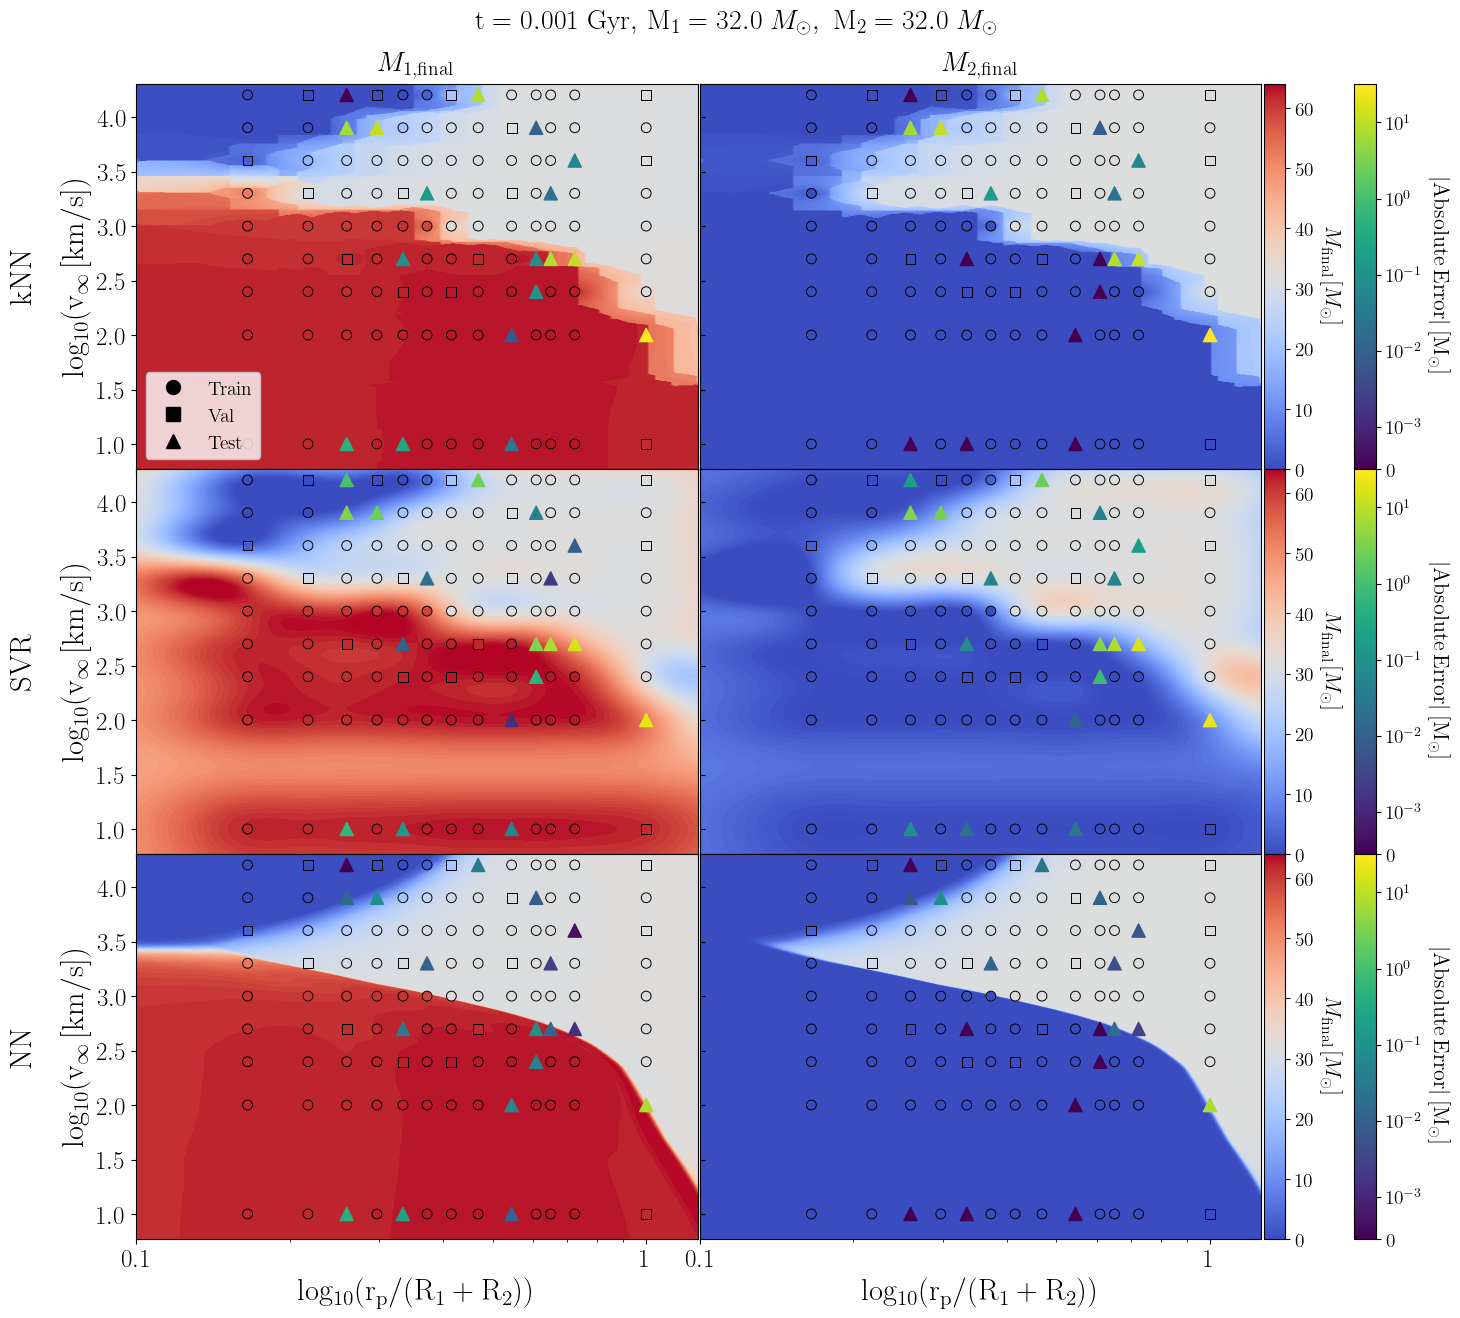

In [7]:

unique_pairs = [[np.log10(0.001+ 0.001), np.log(32.), np.log(32.)]]
methods = ['kNN', 'SVR', 'NN']
num_rows = len(methods)


# Create figure and axes grid
# fig, axes = plt.subplots(num_rows, num_cols, 
#                          figsize=(16*num_cols, 5*num_rows), 
#                          sharey=True)
num_cols = 1 # Two columns: M1, M2, errors
fig, axes = plt.subplots(num_rows, num_cols, 
                         figsize=(16*num_cols, 5*num_rows), 
                         sharey=True, sharex=True)

# Ensure axes is 2D array
if num_rows == 1:
    axes = np.expand_dims(axes, 0)
if num_cols == 1:
    axes = np.expand_dims(axes, 1)

# Remove whitespace between subplots
plt.subplots_adjust(hspace=0, wspace=0)

# Define which panels get legends (row, col)
# Column 0 = M1, Column 1 = M2
legend_panels = {
    (0, 0): [True, False],   # Top-left (M1): data split legend
    (0, 1): [False, True],  # Top-right (M2): no legend (or add class legend if needed)
}

# Since we only have one unique_pair, extract it
unique = unique_pairs[0]
time, mass1, mass2 = unique[0], unique[1], unique[2]

labels = [r'$\rm log_{10}(r_p / (R_1 + R_2))$', r'$\rm log_{10}(v_{\infty} \, [km/s])$', 
          str(round(np.exp(mass1),0)), str(round(np.exp(mass2),0)), 
          str(10**(time) - 0.001)]

# Loop over methods (rows)
for row_idx, method in enumerate(methods):
    print("Method ", method)
    # Get the axis for this row (will be split into M1 and M2    
    ax = axes[row_idx, 0]  # Use the first column position
    
    # Check if this panel should have legends
    legends = legend_panels.get((row_idx, 0), [False, False])
    
    # Plot using your function - this will create M1 and M2 subpanels
    returned_axes = load_and_plot_regression(ax, feature_idx=(1,2),
                                            fixed_values={0: time, 3: mass1, 4: mass2},
                                            labels=labels,
                                            method=method,
                                            legends=legends, 
                                            row_idx=row_idx)
    
    # returned_axes is [ax_M1, ax_M2]
    # Now handle the axis labels and formatting
    for col_idx, ax_curr in enumerate(returned_axes):
        # Only show titles on top row
        if row_idx != 0:
            ax_curr.set_title('')
        
        # Only show x-axis label on bottom row
        if row_idx != num_rows - 1:
            ax_curr.set_xlabel('')
        else:
            ax_curr.set_xlabel(labels[0], fontsize=22)
        
        # Only show y-axis label on leftmost column (M1 panel)
        if col_idx != 0:
            ax_curr.set_ylabel('')
        else:
            ax_curr.set_ylabel(labels[1], fontsize=22)
        
        # Increase tick label sizes
        ax_curr.tick_params(axis='both', which='major', labelsize=18)
    
    # Add row method labels on the left side of M1 panel
    ax_M1 = returned_axes[0]
    ax_M1.text(-0.2, 0.5, rf"$\rm {method}$", transform=ax_M1.transAxes, 
               fontsize=22, va='center', ha='center', rotation=90, weight='bold')


fig.suptitle(fr"$\mathrm{{t}} = {round(10**(time) - 0.001,5)}\ \mathrm{{Gyr}}, \, \mathrm{{M_1}} = {round(np.exp(mass1),0)}\ M_\odot,\ \mathrm{{M_2}} = {round(np.exp(mass2),0)}\ M_\odot $", fontsize = 20, y=0.93)

# plt.tight_layout()
plt.subplots_adjust(hspace=0.00, wspace=0.00)  # Small horizontal space between M1 and M2
fig.savefig('../figures/regression.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Error Distribution ##

In [23]:
def plot_errors(model, X_train, y_train, X_val, y_val, X_test, y_test, train_mean, train_std,
                feature_idx=(0, 1), fixed_values={}, labels=[], 
                point_labels_train=None, point_labels_val=None, point_labels_test=None):
    """
    Plots regression outputs for a PyTorch model using a 2D slice of a higher-dimensional space.
    Points are color-coded by absolute/relative error and labeled with numbers.
    Shows 4 panels: absolute errors (top) and relative errors (bottom) for both star masses.
    
    Parameters:
    - model: Trained PyTorch model.
    - X_train, y_train: Training dataset.
    - X_val, y_val: Validation dataset.
    - X_test, y_test: Test dataset.
    - train_mean, train_std: normalization stats.
    - feature_idx: Tuple (i, j) specifying which two features to plot.
    - fixed_values: {feature_index: value} for fixing other dimensions.
    - labels: list of strings for axis and titles. Expected: [x_label, y_label, ..., etc].
    - point_labels_train: array of labels/numbers to show for each training point
    - point_labels_val: array of labels/numbers for validation points
    - point_labels_test: array of labels/numbers to show for each test point
    """
    import torch
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors

    # Step 1: Normalize fixed values
    fixed_values_norm = {k: (v - train_mean[k]) / train_std[k] for k, v in fixed_values.items()}
    
    train_mask = np.logical_and.reduce([np.isclose(X_train[:, k], v, rtol=0.01) for k, v in fixed_values_norm.items()])
    val_mask = np.logical_and.reduce([np.isclose(X_val[:, k], v, rtol=0.01) for k, v in fixed_values_norm.items()])
    test_mask = np.logical_and.reduce([np.isclose(X_test[:, k], v, rtol=0.01) for k, v in fixed_values_norm.items()])

    if (train_mask.sum() == 0 and val_mask.sum() == 0 and test_mask.sum() == 0):
        return "No data points!"

    X_train_filtered, y_train_filtered = X_train[train_mask], y_train[train_mask]
    X_val_filtered, y_val_filtered = X_val[val_mask], y_val[val_mask]
    X_test_filtered, y_test_filtered = X_test[test_mask], y_test[test_mask]

    # Filter point labels as well
    if point_labels_train is not None:
        point_labels_train_filtered = point_labels_train[train_mask]
    else:
        point_labels_train_filtered = None
        
    if point_labels_val is not None:
        point_labels_val_filtered = point_labels_val[val_mask]
    else:
        point_labels_val_filtered = None
        
    if point_labels_test is not None:
        point_labels_test_filtered = point_labels_test[test_mask]
    else:
        point_labels_test_filtered = None

    # Step 2: Unnormalize data
    X_train_filtered_unnorm = np.array(X_train_filtered) * train_std + train_mean
    X_val_filtered_unnorm = np.array(X_val_filtered) * train_std + train_mean
    X_test_filtered_unnorm = np.array(X_test_filtered) * train_std + train_mean

    y_train_filtered_unnorm = np.array(y_train_filtered) 
    y_val_filtered_unnorm = np.array(y_val_filtered)
    y_test_filtered_unnorm = np.array(y_test_filtered) 

    #Convert masses into not logged 
    X_train_filtered_unnorm[:,3] = np.exp(X_train_filtered_unnorm[:,3])
    X_train_filtered_unnorm[:,4] = np.exp(X_train_filtered_unnorm[:,4])

    # Convert fractions to actual masses
    y_train_filtered_unnorm[:,0] = y_train_filtered_unnorm[:,0] * (X_train_filtered_unnorm[:,3] + X_train_filtered_unnorm[:,4])
    y_train_filtered_unnorm[:,1] = y_train_filtered_unnorm[:,1] * (X_train_filtered_unnorm[:,3] + X_train_filtered_unnorm[:,4])

    y_val_filtered_unnorm[:,0] = y_val_filtered_unnorm[:,0] * (X_val_filtered_unnorm[:,3] + X_val_filtered_unnorm[:,4])
    y_val_filtered_unnorm[:,1] = y_val_filtered_unnorm[:,1] * (X_val_filtered_unnorm[:,3] + X_val_filtered_unnorm[:,4])

    y_test_filtered_unnorm[:,0] = y_test_filtered_unnorm[:,0] * (X_test_filtered_unnorm[:,3] + X_test_filtered_unnorm[:,4])
    y_test_filtered_unnorm[:,1] = y_test_filtered_unnorm[:,1] * (X_test_filtered_unnorm[:,3] + X_test_filtered_unnorm[:,4])

    # Step 3: Get model predictions for the filtered data
    model.eval()
    with torch.no_grad():
        # Predictions for training data
        X_train_tensor = torch.tensor(X_train_filtered, dtype=torch.float32).to(device)
        preds_train = model(X_train_tensor).detach().cpu().numpy()
        
        # Predictions for validation data
        X_val_tensor = torch.tensor(X_val_filtered, dtype=torch.float32).to(device)
        preds_val = model(X_val_tensor).detach().cpu().numpy()
        
        # Predictions for test data  
        X_test_tensor = torch.tensor(X_test_filtered, dtype=torch.float32).to(device)
        preds_test = model(X_test_tensor).detach().cpu().numpy()

    # Convert predicted fractions to actual masses
    preds_train_mass = np.zeros_like(preds_train)
    preds_train_mass[:,0] = preds_train[:,0] * (X_train_filtered_unnorm[:,3] + X_train_filtered_unnorm[:,4])
    preds_train_mass[:,1] = preds_train[:,1] * (X_train_filtered_unnorm[:,3] + X_train_filtered_unnorm[:,4])
    
    preds_val_mass = np.zeros_like(preds_val)
    preds_val_mass[:,0] = preds_val[:,0] * (X_val_filtered_unnorm[:,3] + X_val_filtered_unnorm[:,4])
    preds_val_mass[:,1] = preds_val[:,1] * (X_val_filtered_unnorm[:,3] + X_val_filtered_unnorm[:,4])
    
    preds_test_mass = np.zeros_like(preds_test)
    preds_test_mass[:,0] = preds_test[:,0] * (X_test_filtered_unnorm[:,3] + X_test_filtered_unnorm[:,4])
    preds_test_mass[:,1] = preds_test[:,1] * (X_test_filtered_unnorm[:,3] + X_test_filtered_unnorm[:,4])

    # Step 4: Calculate absolute and relative errors
    abs_error_train = np.abs(preds_train_mass - y_train_filtered_unnorm)
    abs_error_val = np.abs(preds_val_mass - y_val_filtered_unnorm)
    abs_error_test = np.abs(preds_test_mass - y_test_filtered_unnorm)
    
    # Calculate relative errors (avoid division by zero)
    rel_error_train = np.zeros_like(abs_error_train)
    rel_error_val = np.zeros_like(abs_error_val)
    rel_error_test = np.zeros_like(abs_error_test)
    
    # Only calculate relative error where true value > small threshold
    threshold = 0.01  # Solar masses
    
    for i in range(2):  # For both star masses
        train_nonzero = y_train_filtered_unnorm[:, i] > threshold
        val_nonzero = y_val_filtered_unnorm[:, i] > threshold
        test_nonzero = y_test_filtered_unnorm[:, i] > threshold
        
        if train_nonzero.sum() > 0:
            rel_error_train[train_nonzero, i] = abs_error_train[train_nonzero, i] / y_train_filtered_unnorm[train_nonzero, i]
        if val_nonzero.sum() > 0:
            rel_error_val[val_nonzero, i] = abs_error_val[val_nonzero, i] / y_val_filtered_unnorm[val_nonzero, i]
        if test_nonzero.sum() > 0:
            rel_error_test[test_nonzero, i] = abs_error_test[test_nonzero, i] / y_test_filtered_unnorm[test_nonzero, i]

    # Step 5: Create 4-panel plot (2x2 grid)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Set color scales
    all_abs_errors = [abs_error_train, abs_error_val, abs_error_test]
    all_rel_errors = [rel_error_train, rel_error_val, rel_error_test]
    
    abs_error_max = max([err.max() for err in all_abs_errors])
    rel_error_max = max([err.max() for err in all_rel_errors])
    
    cmap = plt.cm.Reds  # Use Reds colormap where darker = higher error
    abs_norm = mcolors.Normalize(vmin=0, vmax=abs_error_max)
    rel_norm = mcolors.Normalize(vmin=0, vmax=min(rel_error_max, 5.0))  # Cap relative error display at 500%

    def plot_scatter_with_labels(ax, X_data, error_data, labels, norm, marker, dataset_name, alpha=0.8):
        """Helper function to plot scatter points with labels"""
        if len(X_data) > 0:
            scatter = ax.scatter(X_data[:, feature_idx[0]], X_data[:, feature_idx[1]],
                               c=error_data, cmap=cmap, norm=norm, 
                               marker=marker, s=60, alpha=alpha,
                               edgecolor="k", linewidth=0.5,
                               label=dataset_name)
            
            # Add labels if provided
            if labels is not None:
                for j, label in enumerate(labels):
                    ax.annotate(str(label), 
                               (X_data[j, feature_idx[0]], X_data[j, feature_idx[1]]),
                               xytext=(3, 3), textcoords='offset points',
                               fontsize=7, ha='left', va='bottom',
                               bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
            return scatter
        return None

    # Plot titles and labels
    star_names = ['Star 1 Final Mass', 'Star 2 Final Mass']
    error_types = ['Absolute Error', 'Relative Error']
    
    for i in range(2):  # Star 1 and Star 2
        for j in range(2):  # Absolute and Relative errors
            ax = axes[j, i]
            
            if j == 0:  # Absolute error row
                error_train = abs_error_train[:, i]
                error_val = abs_error_val[:, i]
                error_test = abs_error_test[:, i]
                norm = abs_norm
                unit_label = "(Solar Masses)"
            else:  # Relative error row
                error_train = rel_error_train[:, i]
                error_val = rel_error_val[:, i]
                error_test = rel_error_test[:, i]
                norm = rel_norm
                unit_label = "(Fractional)"
            
            # Plot datasets
            plot_scatter_with_labels(ax, X_train_filtered_unnorm, error_train, 
                                   point_labels_train_filtered, norm, "o", "Train")
            plot_scatter_with_labels(ax, X_val_filtered_unnorm, error_val, 
                                   point_labels_val_filtered, norm, "s", "Val")
            plot_scatter_with_labels(ax, X_test_filtered_unnorm, error_test, 
                                   point_labels_test_filtered, norm, "^", "Test")

            ax.set_xlabel(fr"{labels[0]}" if len(labels) > 0 else "Feature 1", fontsize=12)
            ax.set_ylabel(fr"{labels[1]}" if len(labels) > 1 else "Feature 2", fontsize=12)
            ax.tick_params(axis='both', which='major', labelsize=10)
            ax.set_title(f'{star_names[i]} - {error_types[j]}', fontsize=13)
            ax.legend(fontsize=10)
            ax.grid(True, alpha=0.3)
    
    # Create colorbars
    plt.tight_layout(rect=[0, 0, 0.85, 0.95])  # Leave space for colorbars and title
    
    # Absolute error colorbar (for top row)
    abs_cbar_ax = fig.add_axes([0.87, 0.55, 0.02, 0.35])
    abs_cbar = fig.colorbar(plt.cm.ScalarMappable(norm=abs_norm, cmap=cmap),
                           cax=abs_cbar_ax, orientation='vertical')
    abs_cbar.set_label('Absolute Error\n(Solar Masses)', fontsize=11)
    
    # Relative error colorbar (for bottom row)
    rel_cbar_ax = fig.add_axes([0.87, 0.1, 0.02, 0.35])
    rel_cbar = fig.colorbar(plt.cm.ScalarMappable(norm=rel_norm, cmap=cmap),
                           cax=rel_cbar_ax, orientation='vertical')
    rel_cbar.set_label('Relative Error\n(Fractional)', fontsize=11)

    # Title
    if len(labels) >= 5:
        fig.suptitle(fr"$\mathrm{{M_1}} = {labels[2]}\ M_\odot,\ \mathrm{{M_2}} = {labels[3]}\ M_\odot,\ \mathrm{{Time}} = {round(10**(float(labels[4])),3)}\ \mathrm{{Gyr}}$", 
                     fontsize=16, y=0.98)

    return fig



In [14]:
def plot_4d_regression(ax, model, X_train, y_train, X_test, y_test, train_mean, train_std,
                       feature_idx=(0, 1), fixed_values={}, labels=[] ):
    """
    Plots regression outputs for a PyTorch model using a 2D slice of a higher-dimensional space.
    Produces one panel per output dimension (color gradient).
    
    Parameters:
    - model: Trained PyTorch model.
    - X_train, y_train, X_test, y_test: datasets.
    - train_mean, train_std: normalization stats.
    - feature_idx: Tuple (i, j) specifying which two features to plot.
    - fixed_values: {feature_index: value} for fixing other dimensions.
    - labels: list of strings for axis and titles. Expected: [x_label, y_label, ..., etc].
    """

    # Step 1: Normalize fixed values
    fixed_values_norm = {k: (v - train_mean[k]) / train_std[k] for k, v in fixed_values.items()}

    train_mask = np.logical_and.reduce([np.isclose(X_train[:, k], v, rtol=0.01) for k, v in fixed_values_norm.items()])
    test_mask = np.logical_and.reduce([np.isclose(X_test[:, k], v, rtol=0.01) for k, v in fixed_values_norm.items()])

    if (train_mask.sum() == 0 and test_mask.sum() == 0):
        return "No data points!"

    X_train_filtered, y_train_filtered = X_train[train_mask], y_train[train_mask]
    X_test_filtered, y_test_filtered = X_test[test_mask], y_test[test_mask]

    # Step 2: Create meshgrid
    X_train_filtered_unnorm = np.array(X_train_filtered) * train_std + train_mean
    X_test_filtered_unnorm = np.array(X_test_filtered) * train_std + train_mean

    #Convert masses into not logged 
    X_train_mass1 = np.exp(X_train_filtered_unnorm[:,3])
    X_train_mass2 = np.exp(X_train_filtered_unnorm[:,4])

    X_test_mass1 = np.exp(X_test_filtered_unnorm[:,3])
    X_test_mass2 = np.exp(X_test_filtered_unnorm[:,4])

    y_train_filtered_unnorm = np.array(y_train_filtered) 
    y_test_filtered_unnorm = np.array(y_test_filtered) 

    # Correct Units 
    y_train_filtered_unnorm[:,0] = y_train_filtered_unnorm[:,0] * (X_train_mass1 + X_train_mass2)
    y_train_filtered_unnorm[:,1] = y_train_filtered_unnorm[:,1] * (X_train_mass1 + X_train_mass2)

    y_test_filtered_unnorm[:,0] = y_test_filtered_unnorm[:,0] * (X_test_mass1 + X_test_mass2)
    y_test_filtered_unnorm[:,1] = y_test_filtered_unnorm[:,1] * (X_test_mass1 + X_test_mass2)
    
    x_min, x_max = X_train_filtered_unnorm[:, feature_idx[0]].min() - 0.1, X_train_filtered_unnorm[:, feature_idx[0]].max() + 0.1
    y_min, y_max = X_train_filtered_unnorm[:, feature_idx[1]].min() - 0.1, X_train_filtered_unnorm[:, feature_idx[1]].max() + 0.1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))

    # Normalize grid
    xx_norm = (xx - train_mean[feature_idx[0]]) / train_std[feature_idx[0]]
    yy_norm = (yy - train_mean[feature_idx[1]]) / train_std[feature_idx[1]]

    # Step 3: Build input space
    X_vis = torch.zeros((xx_norm.ravel().shape[0], X_train.shape[1]), dtype=torch.float32)
    X_vis[:, feature_idx[0]] = torch.tensor(xx_norm.ravel(), dtype=torch.float32)
    X_vis[:, feature_idx[1]] = torch.tensor(yy_norm.ravel(), dtype=torch.float32)
    
    for k, v in fixed_values_norm.items():
        X_vis[:, k] = v

    # Step 4: Model predictions
    X_vis = X_vis.to(device)
    model.eval()
    with torch.no_grad():
        preds = model(X_vis).detach().cpu().numpy()   # shape (Ngrid, 2)

    # Changing the training and testing data to be M1f and M2f 
        
    y_train_filtered_corrected = np.empty((len(y_train_filtered_unnorm[:,0]), 2))
    y_test_filtered_corrected = np.empty((len(y_test_filtered_unnorm[:,0]), 2))
    
    y_train_filtered_corrected[:,0] = y_train_filtered_unnorm[:, 0]
    y_train_filtered_corrected[:,1] = y_train_filtered_unnorm[:, 1] 

    y_test_filtered_corrected[:,0] = y_test_filtered_unnorm[:, 0]
    y_test_filtered_corrected[:,1] = y_test_filtered_unnorm[:, 1] 

    M1_f = preds[:,0] * (np.exp(fixed_values[3]) + np.exp(fixed_values[4]))
    M2_f = preds[:,1] * (np.exp(fixed_values[3]) + np.exp(fixed_values[4]))

    # Reshape into grid for each output dimension
    M1_f = M1_f.reshape(xx.shape)
    M2_f = M2_f.reshape(xx.shape)

    # Step 5: Plot two panels
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    vmin = min(y_train_filtered_corrected[:,0].min(), y_train_filtered_corrected[:,1].min(),
           y_test_filtered_corrected[:,0].min(), y_test_filtered_corrected[:,1].min(),
           M1_f.min(), M2_f.min())
    vmax = max(y_train_filtered_corrected[:,0].max(), y_train_filtered_corrected[:,1].max(),
           y_test_filtered_corrected[:,0].max(), y_test_filtered_corrected[:,1].max(),
           M1_f.max(), M2_f.max())
    
    cmap = plt.cm.coolwarm
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    for i, (Z, ax, title) in enumerate(zip([M1_f, M2_f], axes, ['Star 1 Final Mass', 'Star 2 Final Mass'])):
        im = ax.contourf(xx, yy, Z, levels = 100, cmap=cmap, norm = norm)
        scatter1 = ax.scatter(X_train_filtered_unnorm[:, feature_idx[0]],
                              X_train_filtered_unnorm[:, feature_idx[1]],
                              c=y_train_filtered_corrected[:, i], cmap=cmap, norm = norm, edgecolor="k", marker="o", label="Train")
        scatter2 = ax.scatter(X_test_filtered_unnorm[:, feature_idx[0]],
                              X_test_filtered_unnorm[:, feature_idx[1]],
                              c=y_test_filtered_corrected[:, i], cmap=cmap, norm = norm, marker="^", label="Test")

        ax.set_xlabel(fr"{labels[0]}", fontsize=14)
        ax.set_ylabel(fr"{labels[1]}", fontsize=14)
        ax.tick_params(axis='both', which='major', labelsize=12)
        ax.set_title(title, fontsize=15)
    
   
    # After plotting the contours and scatters
    plt.tight_layout(rect=[0,0,0.9,1])  # leave 10% space on the right for the colorbar

    # Create the colorbar on a dedicated axis outside the panels
    cbar_ax = fig.add_axes([0.9999, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                    cax=cbar_ax, orientation='vertical', shrink=0.8)
    cbar.set_label('Final Mass', fontsize=14)

    fig.suptitle(fr"$\mathrm{{M_1}} = {labels[2]}\ M_\odot,\ \mathrm{{M_2}} = {labels[3]}\ M_\odot,\ \mathrm{{Time}} = {round(10**(float(labels[4])),3)}\ \mathrm{{Gyr}}$", fontsize = 17)

    plt.tight_layout()
    return fig

## Violin Plots ##

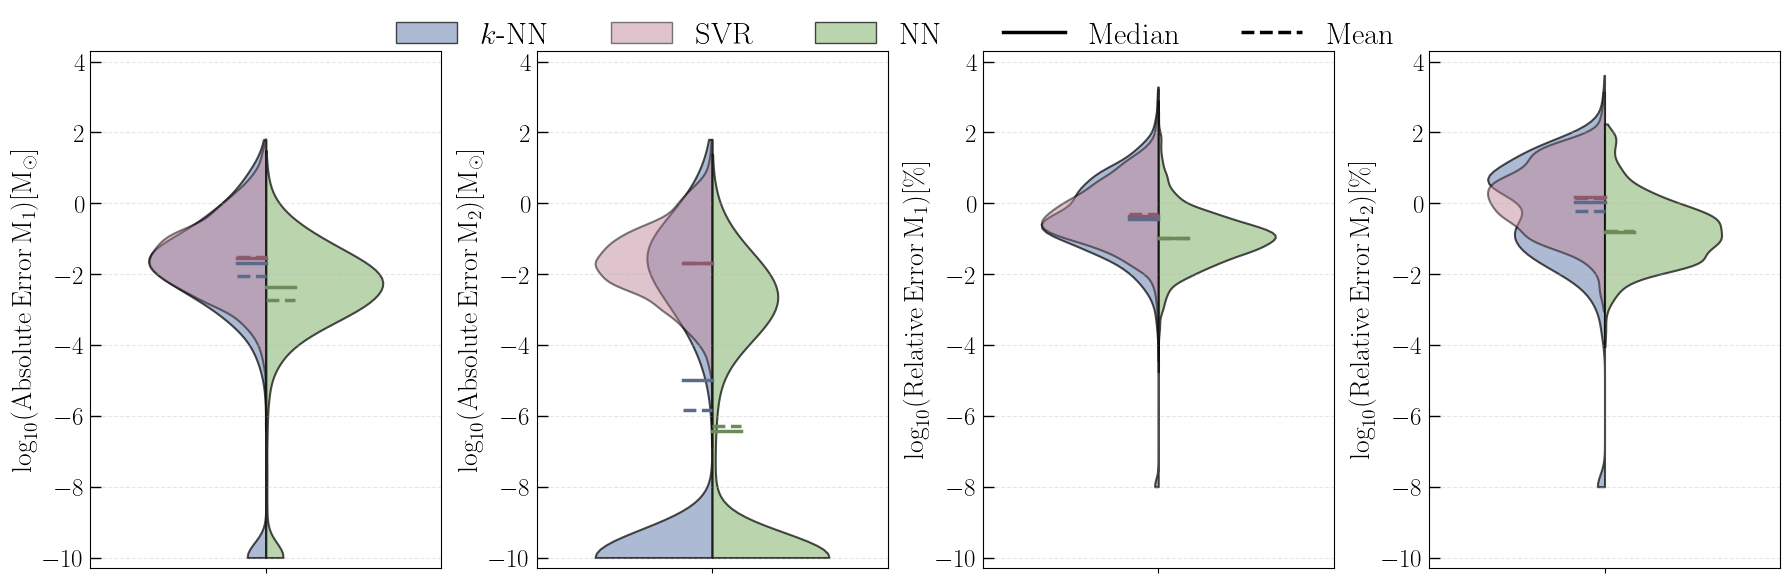

In [22]:
def violin_plots():
    import numpy as np
    import matplotlib.pyplot as plt
    import sys
    sys.path.insert(0, './NN/')
    import os
    
    # --- Load saved results ---
    methods = ['./results/knn_results.npz', './results/svr_results_rbf.npz', './results/NN_results.npz']
    method_names = [r'$k-$' + 'NN', 'SVR', 'NN']
    colors = ['#8B9DC3', '#C38B9D', '#9DC38B']  # Different color for each method
    median_colors = ['#5A6B8C', '#8C5A6B', '#6B8C5A']
    # Load all data first
    all_methods_data = []
    for method in methods:
        data = np.load(method, allow_pickle=True)
        pred_mass1_test, pred_mass2_test = data["y_pred_test"] 
        true_mass1_test, true_mass2_test = data["y_true_test"] 

        
        all_methods_data.append({
            'pred_m1': pred_mass1_test,
            'pred_m2': pred_mass2_test,
            'true_m1': true_mass1_test,
            'true_m2': true_mass2_test
        })
    
    # Define the four plots
    plot_configs = [
        {'title': 'Absolute Error: Mass 1 ', 'ylabel': r'$\log_{10}(\rm Absolute \, Error \, M_1) [M_\odot]$', 'mass': 'm1', 'error_type': 'abs'},
        {'title': 'Absolute Error: Mass 2', 'ylabel': r'$\log_{10}(\rm Absolute  \, Error \, M_2) [M_\odot] $', 'mass': 'm2', 'error_type': 'abs'},
        {'title': 'Relative Error: Mass 1', 'ylabel': r'$\log_{10}(\rm Relative \, Error \, M_1) [\%]$', 'mass': 'm1', 'error_type': 'rel'},
        {'title': 'Relative Error: Mass 2', 'ylabel': r'$\log_{10}(\rm Relative \, Error \, M_2) [\%]$', 'mass': 'm2', 'error_type': 'rel'}
    ]
    
    # Create subplots - 1 row, 4 columns
    fig, axes = plt.subplots(1, 4, figsize=(18, 6))
    
    # Create each subplot
    for ax_idx, (ax, config) in enumerate(zip(axes, plot_configs)):
        # Collect data for this plot
        errors = []
        
        for method_idx, method_data in enumerate(all_methods_data):
            # Get the appropriate mass
            if config['mass'] == 'm1':
                pred = method_data['pred_m1']
                true = method_data['true_m1']
            else:
                pred = method_data['pred_m2']
                true = method_data['true_m2']
            
            # Calculate error
            if config['error_type'] == 'abs':
                error = np.log10(np.abs(pred - true) + 1e-10) 

            else:  # relative error
                pred = pred[true > 0.0]
                true = true[true > 0.0]
                error = np.log10((np.abs((pred - true) / (true + 1e-10)) + 1e-10) * 100) # Multiply by 100 to get % error
            
            errors.append(error)
        
        position = 1
        
        # Plot KNN on left side
        parts_knn = ax.violinplot([errors[0]], positions=[position], 
                                   showmeans=False, showmedians=False, 
                                   widths=0.8, side='low', showextrema = False)
        for pc in parts_knn['bodies']:
            pc.set_facecolor(colors[0])
            pc.set_alpha(0.7)
            pc.set_edgecolor('black')
            pc.set_linewidth(1.5)
        
        # Plot SVR on left side (overlapping)
        parts_svr = ax.violinplot([errors[1]], positions=[position], 
                                   showmeans=False, showmedians=False, 
                                   widths=0.8, side='low', showextrema = False)
        for pc in parts_svr['bodies']:
            pc.set_facecolor(colors[1])
            pc.set_alpha(0.5)
            pc.set_edgecolor('black')
            pc.set_linewidth(1.5)
        
        # Plot NN on right side
        parts_nn = ax.violinplot([errors[2]], positions=[position], 
                                  showmeans=False, showmedians=False, 
                                  widths=0.8, side='high', showextrema = False)
        for pc in parts_nn['bodies']:
            pc.set_facecolor(colors[2])
            pc.set_alpha(0.7)
            pc.set_edgecolor('black')
            pc.set_linewidth(1.5)
        
        # Add median lines
        median_knn = np.median(errors[0])
        median_svr = np.median(errors[1])
        median_nn = np.median(errors[2])

        mean_knn = np.mean(errors[0])
        mean_svr = np.mean(errors[1])
        mean_nn = np.mean(errors[2])
        
        median_width = 0.1
        
        # Medians for left side
        ax.plot([position - median_width, position], [median_knn, median_knn],
               color=median_colors[0], linewidth=2.5, zorder=3, linestyle='-')
        ax.plot([position - median_width, position], [median_svr, median_svr],
               color=median_colors[1], linewidth=2.5, zorder=3, linestyle='-')

        ax.plot([position - median_width, position], [mean_knn, mean_knn],
               color=median_colors[0], linewidth=2.5, zorder=3, linestyle='--')
        ax.plot([position - median_width, position], [mean_svr, mean_svr],
               color=median_colors[1], linewidth=2.5, zorder=3, linestyle='--')

        # Median for right side
        ax.plot([position, position + median_width], [median_nn, median_nn],
               color=median_colors[2], linewidth=2.5, zorder=3)
        ax.plot([position, position + median_width], [mean_nn, mean_nn],
               color=median_colors[2], linewidth=2.5, zorder=3, linestyle='--')

        # Customize subplot
        ax.set_xticks([position])
        ax.set_xticklabels([''])
        ax.set_ylabel(config['ylabel'], fontsize=20)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.tick_params(axis='y', which='major', length=8, width=1, labelsize=18,direction='in' )
        ax.set_xlim(0.4, 1.6)
        ax.set_ylim(-10.3, 4.3)

    # Create custom legend
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=colors[0], edgecolor='black', alpha=0.7, label= r'$k$' + '-' + r'$\rm NN$'),
        Patch(facecolor=colors[1], edgecolor='black', alpha=0.5, label=r'$ \rm SVR $'),
        Patch(facecolor=colors[2], edgecolor='black', alpha=0.7, label=r'$ \rm NN$ '),
        Line2D([0], [0], color='black', linewidth=2.5, label=r'$\rm Median$'),
        Line2D([0], [0], color='black', linewidth=2.5, label=r'$ \rm Mean $' , linestyle='--')
    ]
    fig.legend(handles=legend_elements, fontsize=22, loc='upper center', 
               bbox_to_anchor=(0.5, 1.02), ncol=5, frameon=False)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # Create directory if it doesn't exist    
    plt.savefig('../figures/violin_comparison.pdf', dpi=300, bbox_inches='tight')
    plt.show()

# Run the function
violin_plots()